# Introducción

Esta línea de código equivale a la instalación de módulos por consola.

In [ ]:
pip install gdown python-dateutil pandas matplotlib seaborn plotly

# Pandas

In [20]:
import pandas

# Crear un DataFrame simple
data = {
    "Nombre": ["Ana", "Luis", "María", "Juan"],
    "Edad": [23, 25, 30, 28],
    "Carrera": ["Ingeniería", "Medicina", None, "Arquitectura"],
    "Promedio": [9.4, 3.5, 6.3, None]
}

df_manual = pandas.DataFrame(data)

df_manual

,Nombre,Edad,Carrera,Promedio
0,Ana,23,Ingeniería,9.4
1,Luis,25,Medicina,3.5
2,María,30,None,6.3
3,Juan,28,Arquitectura,NaN


¿Cómo importo la información de un csv?

In [19]:
df_csv = pandas.read_csv("https://drive.google.com/uc?id=1sTzcEYZlwdSprPamS810YygkHEuQ9s7h", sep=";")

if "Email" in df_csv.columns:
    df_csv = df_csv.drop(columns=["Email"])

#df_csv = df_csv.drop(columns=["email"], errors="ignore")

#try:
#    df_csv = df_csv.drop(columns=["email"])
#except KeyError:
#  print("Error atajado.")
#finally:
#  print("Liberación de recursos.")

df_csv = df_csv.rename(columns={"Rubro": "Carrera"})

df_csv

,Nombre,Edad,Carrera
0,Pepe,36,Marroquinería
1,Cosme,36,Carpintería
2,Román,84,Arquitectura
3,Nerea,24,Medicina
4,Alisa,56,Transporte
5,Úrsula,45,Educación


¿Cómo importo la información de una base de datos?

In [17]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
import gdown
import sqlite3

gdown.download("https://drive.google.com/uc?id=1HZe9Xdq7bbqHOni6k1MXd5rWH92y7oqc", "estudiantes.db", quiet=True)

conn = sqlite3.connect("estudiantes.db")

df_sqlite = pandas.read_sql("SELECT nombre, nacimiento, carrera FROM alumnos", conn)

df_sqlite.columns = df_sqlite.columns.str.capitalize()

def calcular_edad(fecha_nac):
    fecha_nac = datetime.strptime(fecha_nac, "%Y-%m-%d")
    hoy = datetime.today()
    return relativedelta(hoy, fecha_nac).years

df_sqlite["Edad"] = df_sqlite["Nacimiento"].apply(calcular_edad)
# df_sqlite = df_sqlite.drop(columns=["Nacimiento"])

df_sqlite["Carrera"] = df_sqlite["Carrera"].fillna("Desconocida")

df_sqlite

,Nombre,Nacimiento,Carrera,Edad
0,Leopoldo,1993-03-23,Desconocida,33
1,Teresa,2000-11-24,Medicina,25
2,Nancy,1999-08-30,Cocina,26
3,Manfredo,1978-05-06,Derecho,48


¿Cómo unifico las fuentes?

In [21]:
df = pandas.concat([df_manual, df_csv, df_sqlite], ignore_index=True) #* Ignora los indices de cada bd, y crea uno nuevo

df

,Nombre,Edad,Carrera,Promedio,Nacimiento
0,Ana,23,Ingeniería,9.4,NaN
1,Luis,25,Medicina,3.5,NaN
2,María,30,None,6.3,NaN
3,Juan,28,Arquitectura,NaN,NaN
4,Pepe,36,Marroquinería,NaN,NaN
5,Cosme,36,Carpintería,NaN,NaN
6,Román,84,Arquitectura,NaN,NaN
7,Nerea,24,Medicina,NaN,NaN
8,Alisa,56,Transporte,NaN,NaN
9,Úrsula,45,Educación,NaN,NaN


# matplotlib

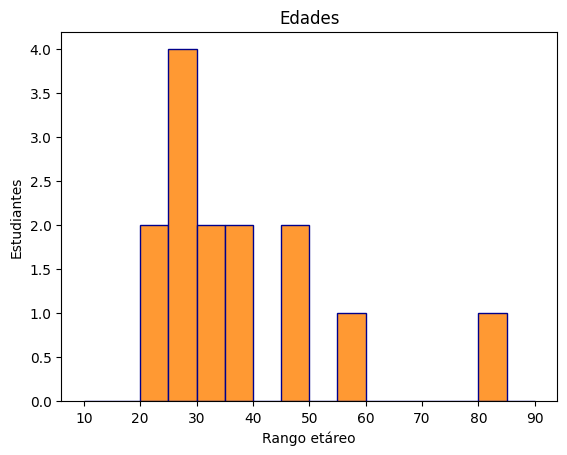

In [36]:
import matplotlib.pyplot as plt

plt.hist(df["Edad"], bins=range(10, 91, 5), color="#f93", edgecolor="darkblue")
#* range(inicio, fin, paso)

plt.title("Edades")
plt.xlabel("Rango etáreo")
plt.ylabel("Estudiantes")

plt.show()


# seaborn

Esta librería sirve más para estadística probabilística que la descriptiva, así que la veremos más adelante.

# plotly

Hay que configurar plotly para que funcione bien en Google Colab (o Jupyter Notebook).

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab" #notebook para Jupyter Notebook


Ahora sí, el ejemplo.

In [38]:
import plotly.express as px

carreras = df["Carrera"].value_counts().reset_index()
carreras.columns = ["Carrera", "Cantidad"]

fig = px.pie(
    carreras,
    values="Cantidad",
    names="Carrera",
    title="Proporción de carreras",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(textinfo="value", textposition="outside")

fig.show()
